In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1]:

def detect_and_adjust_splits(df):
    df = df.sort_values(by='Date').reset_index(drop=True)

    # Calculate the ratio of previous day's Close to current day's Open
    # This ratio tends to be significantly different from 1 on split days
    df['Adj_Ratio'] = df['Open'].shift(-1) / df['Close']
    
    # Identify potential split days: where the ratio is significantly different from 1
    # For example, a 1:2 split would result in Adj_Ratio ~ 0.5 or 2.0
    # We use a threshold to identify these significant changes
    # A common way is to look for ratios far from 1, e.g., < 0.9 or > 1.1
    # We'll use a more robust detection method that considers the effect on all prices.

    # Calculate split factor based on "Close" prices
    # The actual split factor is Previous_Day_Close / Current_Day_Open
    # However, to be more robust, we can compare (previous day's adjusted close) / (current day's close)
    # The typical way to do this is to compare the Close price of today to the Close price of tomorrow
    # considering the change due to split.

    df['Prev_Close'] = df['Close'].shift(1)
    df['Ratio'] = df['Close'] / df['Prev_Close']

    # We look for ratios that are common stock split ratios (e.g., 2, 3, 5, 0.5, 0.333, 0.2)
    # or ratios that are significantly different from 1.
    # Let's consider a threshold, e.g., anything above 1.8 or below 0.6
    # These thresholds are heuristic and might need tuning based on data.
    split_threshold_upper = 1.8
    split_threshold_lower = 0.6

    df['Split_Factor'] = 1.0 # Default no split

    # Iterate backwards to adjust historical data
    for i in range(len(df) - 2, 0, -1):
        if (df.loc[i, 'Ratio'] > split_threshold_upper) or (df.loc[i, 'Ratio'] < split_threshold_lower):
            # Potential split detected
            # The split factor is usually the inverse of what we observe if we divide current/previous
            # For example, if a 2-for-1 split, current price is ~0.5 of previous price
            # So the factor to adjust historical data (before the split day) is 2.0
            
            # Estimate the split factor (round to nearest common split factor)
            # Example: if Ratio is 0.5 (2-for-1 split), then Split_Factor should be 2.0
            # If Ratio is 2.0 (1-for-2 reverse split), then Split_Factor should be 0.5

            if df.loc[i, 'Ratio'] < 1: # Forward split (e.g., 2-for-1)
                factor_raw = 1 / df.loc[i, 'Ratio']
                # Round to nearest integer for common splits (2, 3, 4, 5)
                # Or handle inverse splits like 1:10 as 10
                split_candidates = [2, 3, 4, 5, 10, 20] # Common forward split ratios
                closest_split = min(split_candidates, key=lambda x: abs(x - factor_raw))
                if abs(closest_split - factor_raw) / factor_raw < 0.1: # if within 10%
                    df.loc[i, 'Split_Factor'] = closest_split
                else:
                    df.loc[i, 'Split_Factor'] = factor_raw # Use raw factor if not close to common
                    
            else: # Reverse split (e.g., 1-for-2)
                factor_raw = df.loc[i, 'Ratio']
                split_candidates = [0.5, 0.3333, 0.25, 0.2, 0.1] # Common reverse split ratios (represented as 1/X)
                closest_split = min(split_candidates, key=lambda x: abs(x - (1/factor_raw)))
                if abs(closest_split - (1/factor_raw)) / (1/factor_raw) < 0.1:
                    df.loc[i, 'Split_Factor'] = 1 / closest_split
                else:
                    df.loc[i, 'Split_Factor'] = 1/factor_raw # Use raw factor if not close to common

            # Apply adjustment to all preceding historical data (Open, High, Low, Close, Prev Close, VWAP)
            # Volume is multiplied by the split factor for forward splits and divided for reverse splits
            # which means multiply by Split_Factor
            df.loc[:i-1, ['Open', 'High', 'Low', 'Close', 'Prev Close', 'VWAP']] /= df.loc[i, 'Split_Factor']
            df.loc[:i-1, 'Volume'] *= df.loc[i, 'Split_Factor']

            print(f"Detected split for {df.loc[i, 'Symbol']} on {df.loc[i, 'Date'].strftime('%Y-%m-%d')} with factor {df.loc[i, 'Split_Factor']:.2f}")

    # Drop temporary columns
    df = df.drop(columns=['Adj_Ratio', 'Prev_Close', 'Ratio', 'Split_Factor'])
    return df

import os

def process_all_stock_data(input_folder, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for filename in os.listdir(input_folder):
        if filename.endswith(".csv") and filename != "NIFTY50_all.csv" and filename != "stock_metadata.csv":
            filepath = os.path.join(input_folder, filename)
            stock_symbol = filename.replace(".csv", "")
            
            try:
                df = pd.read_csv(filepath)
                df['Date'] = pd.to_datetime(df['Date'])
                df['Symbol'] = stock_symbol

                # Apply split adjustment
                adjusted_df = detect_and_adjust_splits(df.copy()) # Use a copy to avoid modifying original df in loop

                output_filename = f"{stock_symbol}_adjusted.csv"
                output_filepath = os.path.join(output_folder, output_filename)
                adjusted_df.to_csv(output_filepath, index=False)
                print(f"Processed and saved adjusted data for {stock_symbol}")

            except Exception as e:
                print(f"Error processing {filename}: {e}")

In [4]:
input_folder = 'C:/Users/Dhile/Projects/Stock/Data'
output_folder = 'C:/Users/Dhile/Projects/Stock/Data_adjusted'

process_all_stock_data(input_folder, output_folder)


Detected split for ADANIPORTS on 2010-09-23 with factor 5.00
Processed and saved adjusted data for ADANIPORTS
Detected split for ASIANPAINT on 2013-07-30 with factor 10.00
Detected split for ASIANPAINT on 2000-08-02 with factor 1.71


C:\Users\Dhile\AppData\Local\Temp\ipykernel_28560\2727936671.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[  56580.37486218   82159.2061742    44814.11245865   57194.26681367
  163516.94230062 1028490.70194781 1118135.97941933  423824.18228592
  156354.86953326 1101646.15950018  128525.10106578  130554.35501654
  491113.56119074  925646.74751929  825138.99301727  946484.96876148
  774561.11723631  565394.48732084  829845.49797868  602534.95038589
  509598.52995222  241157.2216097   419953.25248071 1221696.14112459
  117764.93936053  918518.77986035   47644.83645718  233074.3109151
   91214.11245865   61798.45644983  139268.21021683   94761.04373392
  299459.90444689  123682.17567071  112001.17603822  137204.85115766
   47337.89048144   31922.3814774    17223.07975009   35077.10400588
   50543.77067255   23583.68246968   65294.23006248  182462.33002573
   87343.18265344   67800.95553105  382403.52

Processed and saved adjusted data for ASIANPAINT
Detected split for AXISBANK on 2014-07-28 with factor 5.00
Processed and saved adjusted data for AXISBANK
Detected split for BAJAJ-AUTO on 2010-09-08 with factor 2.00
Processed and saved adjusted data for BAJAJ-AUTO
Processed and saved adjusted data for BAJAJFINSV
Detected split for BAJFINANCE on 2016-09-08 with factor 10.00
Processed and saved adjusted data for BAJFINANCE
Detected split for BHARTIARTL on 2009-07-24 with factor 2.00
Processed and saved adjusted data for BHARTIARTL
Detected split for BPCL on 2016-07-13 with factor 2.00
Detected split for BPCL on 2012-07-13 with factor 2.00
Detected split for BPCL on 2000-12-20 with factor 2.00
Processed and saved adjusted data for BPCL
Detected split for BRITANNIA on 2018-11-29 with factor 2.00
Detected split for BRITANNIA on 2010-09-08 with factor 4.00
Processed and saved adjusted data for BRITANNIA
Detected split for CIPLA on 2006-04-24 with factor 2.54
Detected split for CIPLA on 2004-

C:\Users\Dhile\AppData\Local\Temp\ipykernel_28560\2727936671.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[  53481.20908741   76730.04428186   85831.49980747 ... 5208663.45013477
 6372692.37774355 6372994.57450905]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:i-1, 'Volume'] *= df.loc[i, 'Split_Factor']


Processed and saved adjusted data for COALINDIA
Detected split for DRREDDY on 2006-08-28 with factor 2.00
Detected split for DRREDDY on 2001-10-15 with factor 2.00
Processed and saved adjusted data for DRREDDY
Detected split for EICHERMOT on 2020-08-24 with factor 10.00
Processed and saved adjusted data for EICHERMOT
Detected split for GAIL on 2019-07-09 with factor 2.00
Processed and saved adjusted data for GAIL
Detected split for GRASIM on 2016-10-06 with factor 5.00
Processed and saved adjusted data for GRASIM
Detected split for HCLTECH on 2019-12-05 with factor 2.00
Detected split for HCLTECH on 2015-03-19 with factor 2.00
Detected split for HCLTECH on 2007-03-15 with factor 2.00
Detected split for HCLTECH on 2000-11-29 with factor 2.00
Processed and saved adjusted data for HCLTECH
Detected split for HDFC on 2010-08-18 with factor 5.00
Detected split for HDFC on 2002-12-12 with factor 2.00
Processed and saved adjusted data for HDFC
Detected split for HDFCBANK on 2019-09-19 with fac

C:\Users\Dhile\AppData\Local\Temp\ipykernel_28560\2727936671.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[15489513.03851641 19616324.61055635 38045573.61483596 ...
 10332553.81455064 19804302.33380885 28914464.18259629]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:i-1, 'Volume'] *= df.loc[i, 'Split_Factor']


Processed and saved adjusted data for ITC
Detected split for JSWSTEEL on 2017-01-04 with factor 10.00
Processed and saved adjusted data for JSWSTEEL
Detected split for KOTAKBANK on 2015-07-08 with factor 2.00
Detected split for KOTAKBANK on 2010-09-13 with factor 2.00
Detected split for KOTAKBANK on 2005-08-25 with factor 2.29
Detected split for KOTAKBANK on 2004-08-25 with factor 2.00
Detected split for KOTAKBANK on 2001-07-02 with factor 2.57
Processed and saved adjusted data for KOTAKBANK
Detected split for LT on 2008-10-01 with factor 2.00
Detected split for LT on 2006-09-28 with factor 2.00


C:\Users\Dhile\AppData\Local\Temp\ipykernel_28560\2727936671.py:68: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[  64971.01849568  675575.72872996  970063.33415536 ... 1007582.58446363
  535071.08754624 4400754.99876695]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:i-1, 'Volume'] *= df.loc[i, 'Split_Factor']


Processed and saved adjusted data for LT
Processed and saved adjusted data for MARUTI
Detected split for MM on 2017-12-21 with factor 2.00
Detected split for MM on 2010-03-29 with factor 2.00
Detected split for MM on 2005-09-01 with factor 2.00
Processed and saved adjusted data for MM
Processed and saved adjusted data for NESTLEIND
Processed and saved adjusted data for NTPC
Detected split for ONGC on 2011-02-08 with factor 4.00
Processed and saved adjusted data for ONGC
Processed and saved adjusted data for POWERGRID
Detected split for RELIANCE on 2017-09-07 with factor 2.00
Detected split for RELIANCE on 2009-11-26 with factor 2.00
Processed and saved adjusted data for RELIANCE
Detected split for SBIN on 2014-11-20 with factor 10.00
Processed and saved adjusted data for SBIN
Processed and saved adjusted data for SHREECEM
Detected split for SUNPHARMA on 2013-07-29 with factor 2.00
Detected split for SUNPHARMA on 2010-11-25 with factor 5.00
Detected split for SUNPHARMA on 2004-05-27 wit

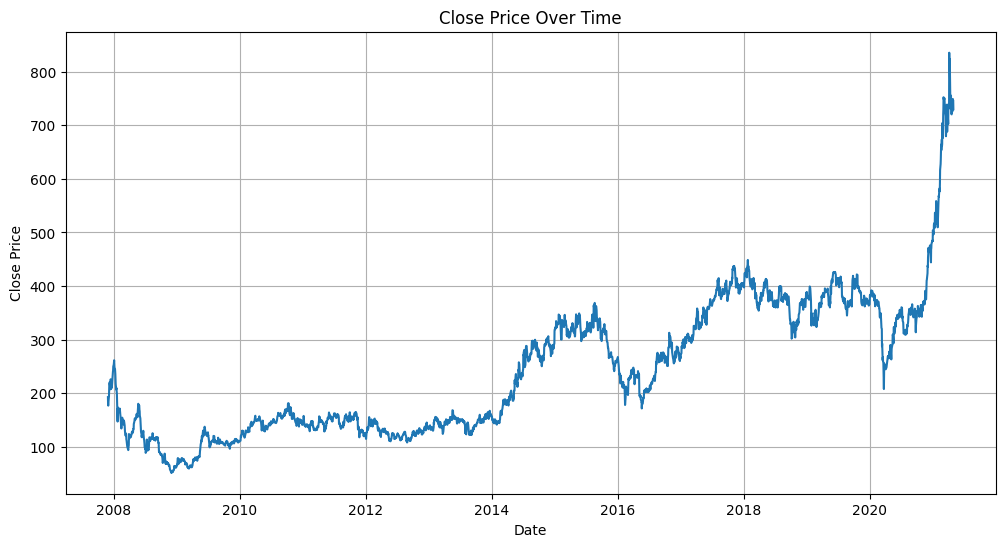

In [8]:
# Load the ADANIPORTS.csv file
df = pd.read_csv('./Data_adjusted/ADANIPORTS_adjusted.csv')


df['Date'] = pd.to_datetime(df['Date'])

# Set the 'Date' column as the new index
df.set_index('Date', inplace=True) 

plt.figure(figsize=(12, 6))
plt.plot(df['Close'])
plt.title('Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()